# AI/ML Task 2: Feature Engineering, Model Optimization & Performance Comparison

**Author:** POLAVARAPU HARI VENKATA SAI  
**Dataset:** California Housing dataset from scikit-learn

This notebook extends Task 1 by adding feature engineering, leakage-safe feature scaling, multiple regression algorithms, and an objective comparison using RMSE and R². The final section selects the best model based on the evaluation results and saves it for optional reuse.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
ROOT = Path('/home/ubuntu/ai_ml_task2')
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Load the California Housing dataset

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)
print(f'Dataset shape: {df.shape}')
display(df.head())
display(df.dtypes.to_frame('data_type'))
print(f'Missing values: {int(df.isna().sum().sum())}')

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,"2,401.0000",2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220


,data_type
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
HousePrice,float64


Missing values: 0


The target `HousePrice` is measured in units of $100,000. All original predictors are numeric, and the dataset contains no missing values.

## 2. Feature engineering

In [3]:
def add_engineered_features(frame):
    result = frame.copy()
    result['RoomsPerPerson'] = result['AveRooms'] / result['AveOccup'].clip(lower=0.1)
    result['BedroomsPerRoom'] = result['AveBedrms'] / result['AveRooms'].clip(lower=0.1)
    return result.replace([np.inf, -np.inf], np.nan).fillna(0)

X = df.drop(columns='HousePrice')
y = df['HousePrice']
X_engineered = add_engineered_features(X)
print('Original feature count:', X.shape[1])
print('Feature count after engineering:', X_engineered.shape[1])
print('Added features:', sorted(set(X_engineered.columns) - set(X.columns)))
display(X_engineered.head())

Original feature count: 8
Feature count after engineering: 10
Added features: ['BedroomsPerRoom', 'RoomsPerPerson']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerPerson,BedroomsPerRoom
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,2.7329,0.1466
1,8.3014,21.0000,6.2381,0.9719,"2,401.0000",2.1098,37.8600,-122.2200,2.9567,0.1558
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,2.9577,0.1295
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,2.2832,0.1845
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,2.8796,0.1721


Two ratio features are added. `RoomsPerPerson` describes the amount of room space relative to average occupancy, while `BedroomsPerRoom` captures the bedroom composition of a property. Ratios can expose relationships that are not explicit in the original columns.

## 3. Train/test split and leakage-safe scaling

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f'Training rows: {len(X_train):,}')
print(f'Test rows: {len(X_test):,}')

# StandardScaler is placed inside each pipeline. It is fitted only on X_train
# and then applied to X_test, preventing information leakage.
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE))
    ])
}

Training rows: 16,512
Test rows: 4,128


Scaling is important for linear models because predictors originally use different numeric ranges. Ridge regression also uses an L2 penalty, so scaling ensures the penalty treats coefficients fairly. The tree model is not sensitive to feature scale, but it is included in the same clean pipeline for consistent preprocessing.

## 4. Train and compare multiple models

In [5]:
results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    results[name] = {
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    }

results_df = pd.DataFrame(results).T.sort_values('RMSE')
results_df.index.name = 'Model'
display(results_df.style.format('{:.4f}'))
results_df.to_csv(ROOT / 'model_comparison.csv')
print(f'Best model by RMSE: {results_df.index[0]}')

,MAE,RMSE,R2
Model,,,
Linear Regression,0.4862,0.6753,0.6519
Ridge Regression,0.4862,0.6754,0.6519
Decision Tree,0.5214,0.7240,0.6000


Best model by RMSE: Linear Regression


Lower RMSE and MAE indicate smaller prediction errors. Higher R² indicates that the model explains more variation in the held-out target. The best model is selected using the lowest test RMSE, with R² used as a supporting measure.

## 5. Visual performance validation

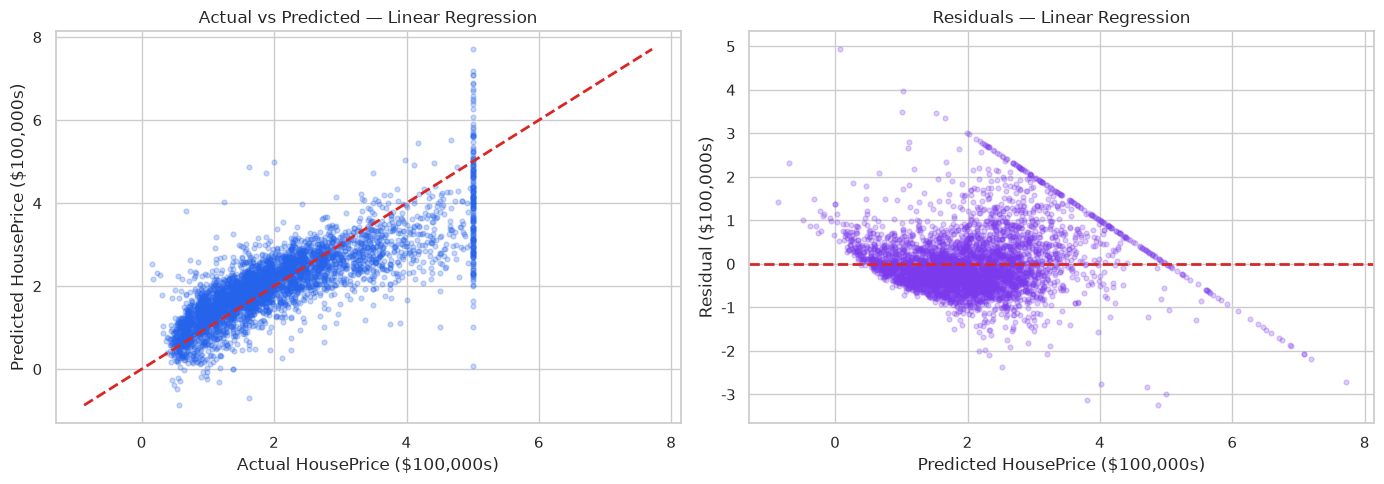

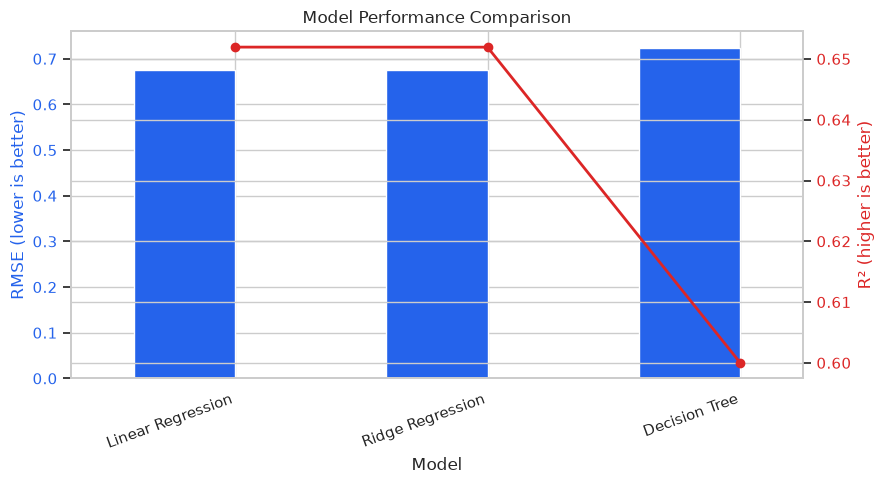

In [6]:
best_name = results_df.index[0]
best_pred = predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, best_pred, alpha=0.25, s=12, color='#2563eb')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, '--', color='#dc2626', linewidth=2)
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].set_xlabel('Actual HousePrice ($100,000s)')
axes[0].set_ylabel('Predicted HousePrice ($100,000s)')

residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.25, s=12, color='#7c3aed')
axes[1].axhline(0, linestyle='--', color='#dc2626', linewidth=2)
axes[1].set_title(f'Residuals — {best_name}')
axes[1].set_xlabel('Predicted HousePrice ($100,000s)')
axes[1].set_ylabel('Residual ($100,000s)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_model_validation.png', dpi=180, bbox_inches='tight')
plt.show()

comparison_plot = results_df[['RMSE', 'R2']].copy()
fig, ax1 = plt.subplots(figsize=(9, 5))
comparison_plot['RMSE'].plot(kind='bar', ax=ax1, color='#2563eb', width=0.4, position=1, label='RMSE')
ax1.set_ylabel('RMSE (lower is better)', color='#2563eb')
ax1.tick_params(axis='y', labelcolor='#2563eb')
ax1.set_xticklabels(comparison_plot.index, rotation=20, ha='right')
ax2 = ax1.twinx()
comparison_plot['R2'].plot(kind='line', ax=ax2, color='#dc2626', marker='o', linewidth=2, label='R²')
ax2.set_ylabel('R² (higher is better)', color='#dc2626')
ax2.tick_params(axis='y', labelcolor='#dc2626')
ax1.set_title('Model Performance Comparison')
fig.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

The actual-versus-predicted plot checks alignment with the ideal diagonal. The residual plot checks for systematic patterns. The comparison chart summarizes the trade-off between lower error and higher explained variance.

## 6. Select and save the best model

In [7]:
best_model = models[best_name]
joblib.dump(best_model, ROOT / 'best_house_price_model.joblib')
summary = {
    'best_model': best_name,
    'metrics': {k: float(v) for k, v in results_df.loc[best_name].to_dict().items()},
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'feature_count': int(X_engineered.shape[1]),
    'features': list(X_engineered.columns)
}
(ROOT / 'task2_summary.json').write_text(json.dumps(summary, indent=2))
print(f'Saved best model: {ROOT / "best_house_price_model.joblib"}')
print(json.dumps(summary, indent=2))

Saved best model: /home/ubuntu/ai_ml_task2/best_house_price_model.joblib
{
  "best_model": "Linear Regression",
  "metrics": {
    "MAE": 0.4861644025414969,
    "RMSE": 0.6753472424631178,
    "R2": 0.6519453808117216
  },
  "train_rows": 16512,
  "test_rows": 4128,
  "feature_count": 10,
  "features": [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
    "RoomsPerPerson",
    "BedroomsPerRoom"
  ]
}


## 7. Conclusion

This Task 2 workflow improves on the baseline by adding meaningful ratio features, applying leakage-safe standardization, training three regression algorithms, and comparing them using the same held-out test set. The model with the lowest RMSE is selected as the final model. The comparison shows why model selection should be evidence-based rather than determined by algorithm popularity. Further improvements could include cross-validation, systematic hyperparameter search, ensemble methods, and stratified evaluation by geography and price range.